In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams["figure.dpi"] = 110
RNG = np.random.default_rng(42)
os.makedirs("outputs", exist_ok=True)

COLUMNS = [
    "checking_status", "duration_in_month", "credit_history", "purpose",
    "credit_amount", "savings_account_bonds", "present_employment_since",
    "installment_rate", "personal_status_sex", "other_debtors_guarantors",
    "present_residence_since", "property", "age_in_years",
    "other_installment_plans", "housing", "number_of_existing_credits",
    "job", "number_of_people_liable", "telephone", "foreign_worker",
    "raw_target",
]

LABEL_MAP_BY_CATEGORY = {
    "checking_status": {
        "A11": "< 0 DM",
        "A12": "0 <= solde < 200 DM",
        "A13": "solde >= 200 DM (ou salaire domicilié >= 1 an)",
        "A14": "pas de compte courant",
    },
    "credit_history": {
        "A30": "aucun crédit ou tous remboursés à temps",
        "A31": "tous les crédits dans cette banque remboursés",
        "A32": "crédits existants remboursés correctement jusqu'ici",
        "A33": "retards de paiement dans le passé",
        "A34": "compte critique / autres crédits existants",
    },
    "purpose": {
        "A40": "voiture (neuve)",
        "A41": "voiture (occasion)",
        "A42": "meubles / équipement",
        "A43": "radio / télévision",
        "A44": "électroménager",
        "A45": "réparations",
        "A46": "éducation",
        "A47": "vacances (valeur indiquée comme non utilisée)",
        "A48": "reconversion",
        "A49": "business",
        "A410": "autres",
    },
    "savings_account_bonds": {
        "A61": "< 100 DM",
        "A62": "100 <= épargne < 500 DM",
        "A63": "500 <= épargne < 1000 DM",
        "A64": "épargne >= 1000 DM",
        "A65": "inconnu / pas de compte épargne",
    },
    "present_employment_since": {
        "A71": "sans emploi",
        "A72": "< 1 an",
        "A73": "1 <= ancienneté < 4 ans",
        "A74": "4 <= ancienneté < 7 ans",
        "A75": "ancienneté >= 7 ans",
    },
    "personal_status_sex": {
        "A91": "homme, divorcé/séparé",
        "A92": "femme, divorcée/séparée/mariée",
        "A93": "homme, célibataire",
        "A94": "homme, marié/veuf",
        "A95": "femme, célibataire",
    },
    "other_debtors_guarantors": {
        "A101": "aucun",
        "A102": "co-demandeur",
        "A103": "garant",
    },
    "property": {
        "A121": "immobilier",
        "A122": "épargne logement / assurance-vie",
        "A123": "voiture ou autre (hors attr. 6)",
        "A124": "inconnu / pas de propriété",
    },
    "other_installment_plans": {
        "A141": "banque",
        "A142": "magasins",
        "A143": "aucun",
    },
    "housing": {
        "A151": "locataire",
        "A152": "propriétaire",
        "A153": "hébergé gratuitement",
    },
    "job": {
        "A171": "sans emploi / non qualifié non-résident",
        "A172": "non qualifié résident",
        "A173": "employé qualifié / officiel",
        "A174": "management / indépendant / hautement qualifié",
    },
    "telephone": {
        "A191": "aucun téléphone",
        "A192": "oui, au nom du client",
    },
    "foreign_worker": {
        "A201": "oui",
        "A202": "non",
    },
}

raw = pd.read_csv("data/raw/german.data", sep=r"\s+", header=None, names=COLUMNS)
for col, mapping in LABEL_MAP_BY_CATEGORY.items():
    raw[col] = raw[col].astype(str).map(mapping).fillna(raw[col].astype(str))
raw["default"] = (raw["raw_target"] == 2).astype(int)

print(f"Dataset : {raw.shape[0]} lignes, {raw.shape[1]} colonnes")
print(f"Taux de défaut : {raw['default'].mean():.1%}")

# 10 premiers demandeurs
raw.head(10)

Dataset : 1000 lignes, 22 colonnes
Taux de défaut : 30.0%


,checking_status,duration_in_month,credit_history,purpose,credit_amount,savings_account_bonds,present_employment_since,installment_rate,personal_status_sex,other_debtors_guarantors,...,age_in_years,other_installment_plans,housing,number_of_existing_credits,job,number_of_people_liable,telephone,foreign_worker,raw_target,default
0,< 0 DM,6,compte critique / autres crédits existants,radio / télévision,1169,inconnu / pas de compte épargne,ancienneté >= 7 ans,4,"homme, célibataire",aucun,...,67,aucun,propriétaire,2,employé qualifié / officiel,1,"oui, au nom du client",oui,1,0
1,0 <= solde < 200 DM,48,crédits existants remboursés correctement jusq...,radio / télévision,5951,< 100 DM,1 <= ancienneté < 4 ans,2,"femme, divorcée/séparée/mariée",aucun,...,22,aucun,propriétaire,1,employé qualifié / officiel,1,aucun téléphone,oui,2,1
2,pas de compte courant,12,compte critique / autres crédits existants,éducation,2096,< 100 DM,4 <= ancienneté < 7 ans,2,"homme, célibataire",aucun,...,49,aucun,propriétaire,1,non qualifié résident,2,aucun téléphone,oui,1,0
3,< 0 DM,42,crédits existants remboursés correctement jusq...,meubles / équipement,7882,< 100 DM,4 <= ancienneté < 7 ans,2,"homme, célibataire",garant,...,45,aucun,hébergé gratuitement,1,employé qualifié / officiel,2,aucun téléphone,oui,1,0
4,< 0 DM,24,retards de paiement dans le passé,voiture (neuve),4870,< 100 DM,1 <= ancienneté < 4 ans,3,"homme, célibataire",aucun,...,53,aucun,hébergé gratuitement,2,employé qualifié / officiel,2,aucun téléphone,oui,2,1
5,pas de compte courant,36,crédits existants remboursés correctement jusq...,éducation,9055,inconnu / pas de compte épargne,1 <= ancienneté < 4 ans,2,"homme, célibataire",aucun,...,35,aucun,hébergé gratuitement,1,non qualifié résident,2,"oui, au nom du client",oui,1,0
6,pas de compte courant,24,crédits existants remboursés correctement jusq...,meubles / équipement,2835,500 <= épargne < 1000 DM,ancienneté >= 7 ans,3,"homme, célibataire",aucun,...,53,aucun,propriétaire,1,employé qualifié / officiel,1,aucun téléphone,oui,1,0
7,0 <= solde < 200 DM,36,crédits existants remboursés correctement jusq...,voiture (occasion),6948,< 100 DM,1 <= ancienneté < 4 ans,2,"homme, célibataire",aucun,...,35,aucun,locataire,1,management / indépendant / hautement qualifié,1,"oui, au nom du client",oui,1,0
8,pas de compte courant,12,crédits existants remboursés correctement jusq...,radio / télévision,3059,épargne >= 1000 DM,4 <= ancienneté < 7 ans,2,"homme, divorcé/séparé",aucun,...,61,aucun,propriétaire,1,non qualifié résident,1,aucun téléphone,oui,1,0
9,0 <= solde < 200 DM,30,compte critique / autres crédits existants,voiture (neuve),5234,< 100 DM,sans emploi,4,"homme, marié/veuf",aucun,...,28,aucun,propriétaire,2,management / indépendant / hautement qualifié,1,aucun téléphone,oui,2,1


# IA Responsable, German Credit Dataset

IA708, Télécom Paris, 2026

Etudiants: 

- Julien GIMENEZ julien.gimenez@telecom-paris.fr
- Hugo FANCHINI hugo.fanchini@telecom-paris.fr
- Paul CINTRA paul.cintra@telecom-paris.fr 
- Yimou ZHANG yimou.zhang@telecom-paris.fr
- Zaher HAMADEH zaher.hamadeh@telecom-paris.fr

Ce notebook s'appuie sur les bibliothèques standard du domaine : scikit-learn, fairlearn, shap.

On étudie un modèle de scoring crédit sous trois angles :
- Équité : le modèle traite-t-il les groupes de manière juste ?
- Interprétabilité : quelles variables influencent les décisions ?
- Quantification d'incertitude : intervalles de confiance par bootstrap

# IA Responsable, German Credit Dataset

IA708, Télécom Paris, 2026

Etudiants: 

- Julien GIMENEZ julien.gimenez@telecom-paris.fr
- Hugo FANCHINI hugo.fanchini@telecom-paris.fr
- Paul CINTRA paul.cintra@telecom-paris.fr 
- Yimou ZHANG yimou.zhang@telecom-paris.fr
- Zaher HAMADEH zaher.hamadeh@telecom-paris.fr

Ce notebook s'appuie sur les bibliothèques standard du domaine : scikit-learn, fairlearn, shap.

On étudie un modèle de scoring crédit sous trois angles :
- Équité : le modèle traite-t-il les groupes de manière juste ?
- Interprétabilité : quelles variables influencent les décisions ?
- Quantification d'incertitude : intervalles de confiance par bootstrap

# IA Responsable, German Credit Dataset

IA708, Télécom Paris, 2026

Etudiants: 

- Julien GIMENEZ julien.gimenez@telecom-paris.fr
- Hugo FANCHINI hugo.fanchini@telecom-paris.fr
- Paul CINTRA paul.cintra@telecom-paris.fr 
- Yimou ZHANG yimou.zhang@telecom-paris.fr
- Zaher HAMADEH zaher.hamadeh@telecom-paris.fr

Ce notebook s'appuie sur les bibliothèques standard du domaine : scikit-learn, fairlearn, shap.

On étudie un modèle de scoring crédit sous trois angles :
- Équité : le modèle traite-t-il les groupes de manière juste ?
- Interprétabilité : quelles variables influencent les décisions ?
- Quantification d'incertitude : intervalles de confiance par bootstrap

In [2]:
EXACT_MEANINGS_PDF = {
    "checking_status": {
        "A11": "... < 0 DM",
        "A12": "0 <= ... < 200 DM",
        "A13": "... >= 200 DM / salary assignments for at least 1 year",
        "A14": "no checking account",
    },
    "credit_history": {
        "A30": "no credits taken / all credits paid back duly",
        "A31": "all credits at this bank paid back duly",
        "A32": "existing credits paid back duly till now",
        "A33": "delay in paying off in the past",
        "A34": "critical account / other credits existing (not at this bank)",
    },
    "purpose": {
        "A40": "car (new)", "A41": "car (used)", "A42": "furniture/equipment",
        "A43": "radio/television", "A44": "domestic appliances", "A45": "repairs",
        "A46": "education", "A47": "(vacation - does not exist?)", "A48": "retraining",
        "A49": "business", "A410": "others",
    },
    "savings_account_bonds": {
        "A61": "... < 100 DM", "A62": "100 <= ... < 500 DM", "A63": "500 <= ... < 1000 DM",
        "A64": "... >= 1000 DM", "A65": "unknown / no savings account",
    },
    "present_employment_since": {
        "A71": "unemployed", "A72": "... < 1 year", "A73": "1 <= ... < 4 years",
        "A74": "4 <= ... < 7 years", "A75": "... >= 7 years",
    },
    "personal_status_sex": {
        "A91": "male : divorced/separated", "A92": "female : divorced/separated/married",
        "A93": "male : single", "A94": "male : married/widowed", "A95": "female : single",
    },
    "other_debtors_guarantors": {
        "A101": "none", "A102": "co-applicant", "A103": "guarantor",
    },
    "property": {
        "A121": "real estate",
        "A122": "if not A121: building society savings agreement/life insurance",
        "A123": "if not A121/A122: car or other, not in attribute 6",
        "A124": "unknown / no property",
    },
    "other_installment_plans": {"A141": "bank", "A142": "stores", "A143": "none"},
    "housing": {"A151": "rent", "A152": "own", "A153": "for free"},
    "job": {
        "A171": "unemployed / unskilled - non-resident",
        "A172": "unskilled - resident",
        "A173": "skilled employee / official",
        "A174": "management / self-employed / highly qualified employee / officer",
    },
    "telephone": {"A191": "none", "A192": "yes, registered under the customer's name"},
    "foreign_worker": {"A201": "yes", "A202": "no"},
}

rows = []
for category, exact_map in EXACT_MEANINGS_PDF.items():
    clear_map = LABEL_MAP_BY_CATEGORY.get(category, {})
    for code, exact_txt in exact_map.items():
        rows.append({
            "Catégorie": category,
            "Code": code,
            "Signification exacte (german.pdf)": exact_txt,
            "Label clair (FR)": clear_map.get(code, ""),
        })
conversion_table = pd.DataFrame(rows).sort_values(["Catégorie", "Code"]).reset_index(drop=True)
print("Table globale: code -> signification exacte -> label clair")
display(conversion_table)

Table globale: code -> signification exacte -> label clair


,Catégorie,Code,Signification exacte (german.pdf),Label clair (FR)
0,checking_status,A11,... < 0 DM,< 0 DM
1,checking_status,A12,0 <= ... < 200 DM,0 <= solde < 200 DM
2,checking_status,A13,... >= 200 DM / salary assignments for at leas...,solde >= 200 DM (ou salaire domicilié >= 1 an)
3,checking_status,A14,no checking account,pas de compte courant
4,credit_history,A30,no credits taken / all credits paid back duly,aucun crédit ou tous remboursés à temps
5,credit_history,A31,all credits at this bank paid back duly,tous les crédits dans cette banque remboursés
6,credit_history,A32,existing credits paid back duly till now,crédits existants remboursés correctement jusq...
7,credit_history,A33,delay in paying off in the past,retards de paiement dans le passé
8,credit_history,A34,critical account / other credits existing (not...,compte critique / autres crédits existants
9,foreign_worker,A201,yes,oui


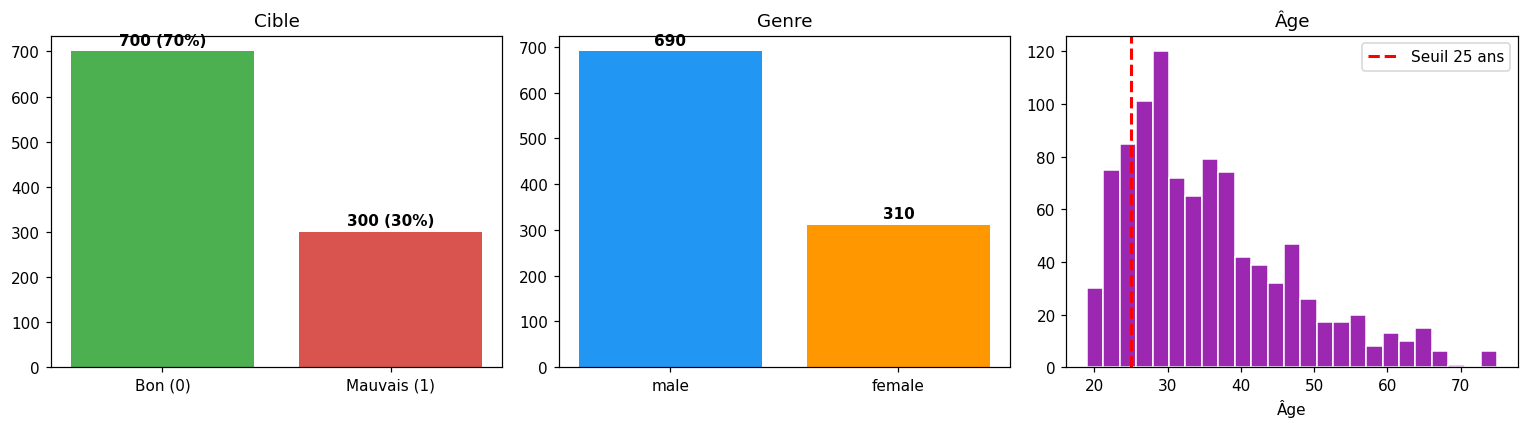

In [3]:
GENDER_MAP = {
    "homme, divorcé/séparé": "male",
    "homme, célibataire": "male",
    "homme, marié/veuf": "male",
    "femme, divorcée/séparée/mariée": "female",
    "femme, célibataire": "female",
}
raw["gender"] = raw["personal_status_sex"].map(GENDER_MAP).fillna("unknown")
raw["age_group"] = np.where(raw["age_in_years"] > 25, "older", "younger")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

c = raw["default"].value_counts().sort_index()
axes[0].bar(["Bon (0)", "Mauvais (1)"], c.values, color=["#4CAF50", "#d9534f"])
axes[0].set_title("Cible")
for i, v in enumerate(c.values):
    axes[0].text(i, v + 15, f"{v} ({v/len(raw):.0%})", ha="center", fontweight="bold")

g = raw["gender"].value_counts()
axes[1].bar(g.index, g.values, color=["#2196F3", "#FF9800"])
axes[1].set_title("Genre")
for i, v in enumerate(g.values):
    axes[1].text(i, v + 15, f"{v}", ha="center", fontweight="bold")

axes[2].hist(raw["age_in_years"], bins=25, color="#9C27B0", edgecolor="white")
axes[2].axvline(25, color="red", ls="--", lw=2, label="Seuil 25 ans")
axes[2].set_title("Âge")
axes[2].legend()
axes[2].set_xlabel("Âge")

plt.tight_layout()
plt.savefig("outputs/01_exploration.png", bbox_inches="tight")
plt.show()

In [4]:
for name, col in [("Genre", "gender"), ("Âge", "age_group")]:
    ct = pd.crosstab(raw[col], raw["default"], normalize="index").round(3)
    ct.columns = ["P(bon)", "P(défaut)"]
    print(f"Taux de défaut par {name}")
    print(ct.to_string(), "\n")


Taux de défaut par Genre
        P(bon)  P(défaut)
gender                   
female   0.648      0.352
male     0.723      0.277 

Taux de défaut par Âge
           P(bon)  P(défaut)
age_group                   
older       0.728      0.272
younger     0.579      0.421 



In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

sensitive = {
    "gender": raw["gender"].values,
    "age": raw["age_group"].values,
}
PRIVILEGED = {"gender": "male", "age": "older"}

features = raw.drop(columns=[
    "raw_target", "default", "personal_status_sex", "age_in_years",
    "gender", "age_group",
])
y = raw["default"].values

NUMERIC = ["duration_in_month", "credit_amount", "installment_rate",
           "present_residence_since", "number_of_existing_credits",
           "number_of_people_liable"]
CATEG = [c for c in features.columns if c not in NUMERIC]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEG),
])

idx = np.arange(len(y))
idx_trval, idx_te = train_test_split(idx, test_size=0.2, stratify=y, random_state=42)
y_trval = y[idx_trval]
idx_tr, idx_va = train_test_split(idx_trval, test_size=0.25, stratify=y_trval, random_state=42)

X_tr = preprocessor.fit_transform(features.iloc[idx_tr])
X_va = preprocessor.transform(features.iloc[idx_va])
X_te = preprocessor.transform(features.iloc[idx_te])
y_tr, y_va, y_te = y[idx_tr], y[idx_va], y[idx_te]

feature_names = preprocessor.get_feature_names_out()
feature_names = [n.split("__", 1)[-1] for n in feature_names]

print(f"Train: {len(idx_tr)}, Val: {len(idx_va)}, Test: {len(idx_te)}")
print(f"Features après encoding : {X_tr.shape[1]} colonnes ({len(NUMERIC)} num, {len(CATEG)} cat)")

Train: 600, Val: 200, Test: 200
Features après encoding : 56 colonnes (6 num, 12 cat)


Convergence (vérification équipe : seuil ~100 itérations, loss attendue ~0.5)
 n_iter  loss_train  loss_val  AUC_val
     10      0.4318    0.5574   0.7276
     25      0.4318    0.5574   0.7276
     50      0.4318    0.5574   0.7276
     75      0.4318    0.5574   0.7276
    100      0.4318    0.5574   0.7276
    150      0.4318    0.5574   0.7276
    200      0.4318    0.5574   0.7276
    500      0.4318    0.5574   0.7276
   1000      0.4318    0.5574   0.7276


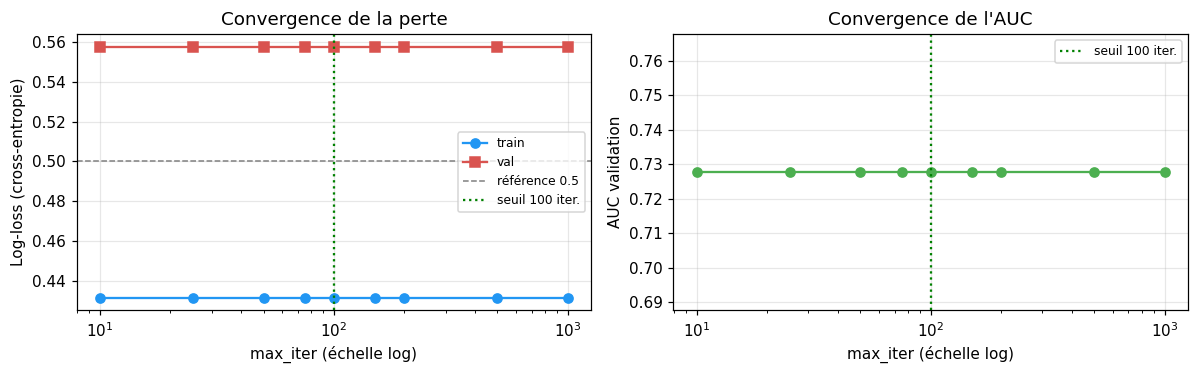


Log-loss train final : 0.4318
Seuil optimal (sur validation) : 0.180
AUC test : 0.7851
Balanced accuracy test : 0.6690


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, log_loss

def best_threshold(y_true, scores):
    # Seuil qui maximise la balanced accuracy sur la validation.
    candidates = np.linspace(0.1, 0.9, 81)
    bas = [balanced_accuracy_score(y_true, (scores >= t).astype(int)) for t in candidates]
    return candidates[int(np.argmax(bas))]

convergence_history = []
for n_iter in [10, 25, 50, 75, 100, 150, 200, 500, 1000]:
    m = LogisticRegression(C=1.0, solver="liblinear", max_iter=n_iter, random_state=42)
    m.fit(X_tr, y_tr)
    p_va = m.predict_proba(X_va)[:, 1]
    convergence_history.append({
        "n_iter": n_iter,
        "loss_train": log_loss(y_tr, m.predict_proba(X_tr)[:, 1]),
        "loss_val": log_loss(y_va, p_va),
        "AUC_val": roc_auc_score(y_va, p_va),
    })
conv_df = pd.DataFrame(convergence_history)
print("Convergence (vérification équipe : seuil ~100 itérations, loss attendue ~0.5)")
print(conv_df.to_string(index=False, float_format="{:.4f}".format))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(conv_df["n_iter"], conv_df["loss_train"], "o-", label="train", color="#2196F3")
axes[0].plot(conv_df["n_iter"], conv_df["loss_val"], "s-", label="val", color="#d9534f")
axes[0].axhline(0.5, color="grey", ls="--", lw=1, label="référence 0.5")
axes[0].axvline(100, color="green", ls=":", lw=1.5, label="seuil 100 iter.")
axes[0].set_xscale("log")
axes[0].set_xlabel("max_iter (échelle log)")
axes[0].set_ylabel("Log-loss (cross-entropie)")
axes[0].set_title("Convergence de la perte")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(conv_df["n_iter"], conv_df["AUC_val"], "o-", color="#4CAF50")
axes[1].axvline(100, color="green", ls=":", lw=1.5, label="seuil 100 iter.")
axes[1].set_xscale("log")
axes[1].set_xlabel("max_iter (échelle log)")
axes[1].set_ylabel("AUC validation")
axes[1].set_title("Convergence de l'AUC")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/00_convergence.png", bbox_inches="tight")
plt.show()

baseline = LogisticRegression(C=1.0, solver="liblinear", max_iter=1000, random_state=42)
baseline.fit(X_tr, y_tr)

scores_va = baseline.predict_proba(X_va)[:, 1]
scores_base = baseline.predict_proba(X_te)[:, 1]
thr_base = best_threshold(y_va, scores_va)
preds_base = (scores_base >= thr_base).astype(int)

print(f"\nLog-loss train final : {log_loss(y_tr, baseline.predict_proba(X_tr)[:, 1]):.4f}")
print(f"Seuil optimal (sur validation) : {thr_base:.3f}")
print(f"AUC test : {roc_auc_score(y_te, scores_base):.4f}")
print(f"Balanced accuracy test : {balanced_accuracy_score(y_te, preds_base):.4f}")


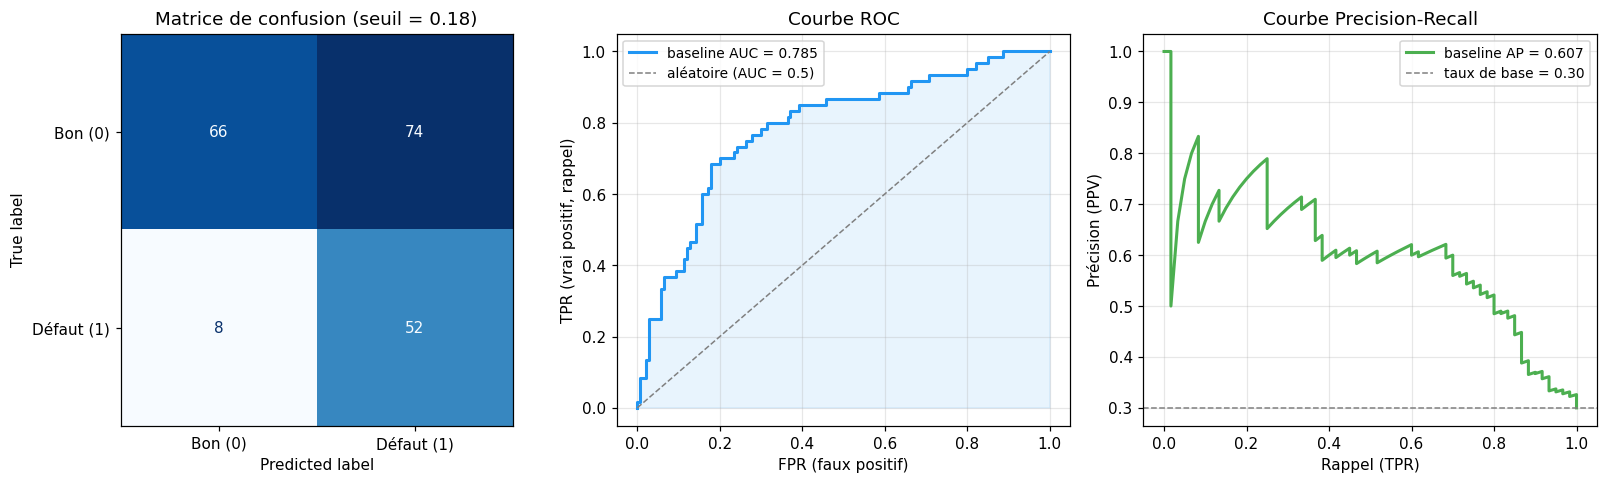

AUC ROC test          : 0.7851
Average Precision (AP): 0.6067
Taux de base (P(défaut) sur test) : 0.3000


In [7]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import (
    roc_curve, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Matrice de confusion (heatmap)
cm = confusion_matrix(y_te, preds_base)
disp = ConfusionMatrixDisplay(cm, display_labels=["Bon (0)", "Défaut (1)"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title(f"Matrice de confusion (seuil = {thr_base:.2f})")
axes[0].grid(False)

# Courbe ROC
fpr, tpr, _ = roc_curve(y_te, scores_base)
auc_test = roc_auc_score(y_te, scores_base)
axes[1].plot(fpr, tpr, color="#2196F3", lw=2, label=f"baseline AUC = {auc_test:.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="grey", lw=1, label="aléatoire (AUC = 0.5)")
axes[1].fill_between(fpr, tpr, alpha=0.1, color="#2196F3")
axes[1].set_xlabel("FPR (faux positif)")
axes[1].set_ylabel("TPR (vrai positif, rappel)")
axes[1].set_title("Courbe ROC")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# Courbe Precision-Recall
prec, rec, _ = precision_recall_curve(y_te, scores_base)
ap = average_precision_score(y_te, scores_base)
axes[2].plot(rec, prec, color="#4CAF50", lw=2, label=f"baseline AP = {ap:.3f}")
axes[2].axhline(y_te.mean(), color="grey", ls="--", lw=1,
                label=f"taux de base = {y_te.mean():.2f}")
axes[2].set_xlabel("Rappel (TPR)")
axes[2].set_ylabel("Précision (PPV)")
axes[2].set_title("Courbe Precision-Recall")
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/10_baseline_perf.png", bbox_inches="tight")
plt.show()

print(f"AUC ROC test          : {auc_test:.4f}")
print(f"Average Precision (AP): {ap:.4f}")
print(f"Taux de base (P(défaut) sur test) : {y_te.mean():.4f}")

                    Modèle    AUC
       Aléatoire stratifié 0.5238
Règle âge (younger=défaut) 0.5810
   Règle checking_status<0 0.6607
     Régression logistique 0.7851


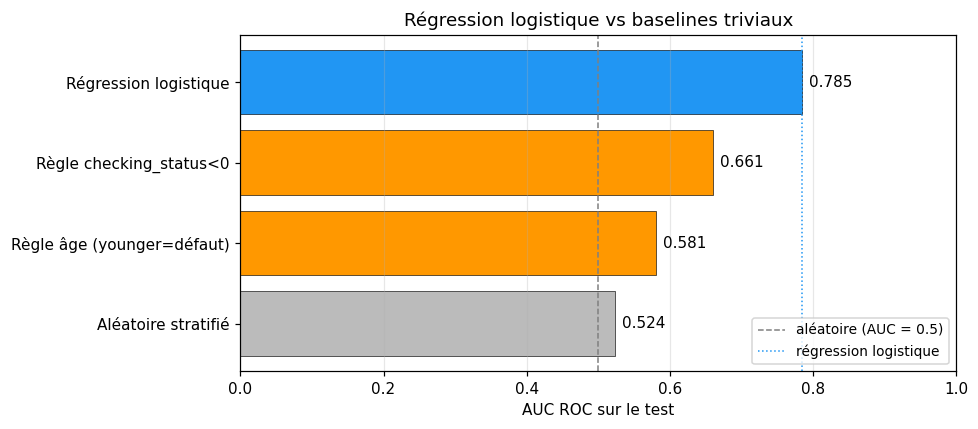

In [8]:
from sklearn.dummy import DummyClassifier

# Baseline 1 : aléatoire stratifié
dummy = DummyClassifier(strategy="stratified", random_state=42)
dummy.fit(X_tr, y_tr)
auc_dummy = roc_auc_score(y_te, dummy.predict_proba(X_te)[:, 1])

# Baseline 2 : règle simple sur l'âge (younger -> défaut)
score_age = (sensitive["age"][idx_te] == "younger").astype(float)
auc_age = roc_auc_score(y_te, score_age)

# Baseline 3 : règle simple sur checking_status (A11 = découvert -> défaut)
score_check = (raw["checking_status"].iloc[idx_te] == "< 0 DM").astype(float).values
auc_check = roc_auc_score(y_te, score_check)

# Comparaison
results = pd.DataFrame([
    {"Modèle": "Aléatoire stratifié",       "AUC": auc_dummy},
    {"Modèle": "Règle âge (younger=défaut)", "AUC": auc_age},
    {"Modèle": "Règle checking_status<0",    "AUC": auc_check},
    {"Modèle": "Régression logistique",      "AUC": 0.7851},
])
print(results.to_string(index=False, float_format="{:.4f}".format))

# Visualisation
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#bbbbbb", "#FF9800", "#FF9800", "#2196F3"]
y_pos = np.arange(len(results))
bars = ax.barh(y_pos, results["AUC"], color=colors, edgecolor="k", lw=0.4)
for i, v in enumerate(results["AUC"]):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center")
ax.axvline(0.5, color="grey", ls="--", lw=1, label="aléatoire (AUC = 0.5)")
ax.axvline(0.785, color="#2196F3", ls=":", lw=1, label="régression logistique")
ax.set_yticks(y_pos)
ax.set_yticklabels(results["Modèle"])
ax.set_xlabel("AUC ROC sur le test")
ax.set_title("Régression logistique vs baselines triviaux")
ax.set_xlim(0, 1)
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("outputs/13_trivial_baselines.png", bbox_inches="tight")
plt.show()

In [9]:
from sklearn.metrics import confusion_matrix

COST_FN = 5  # approuver un mauvais crédit (UCI documentation)
COST_FP = 1  # refuser un bon crédit

def business_cost(y_true, preds):
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    return int(COST_FN * fn + COST_FP * fp)

def best_threshold_cost(y_true, scores):
    candidates = np.linspace(0.01, 0.99, 99)
    costs = [business_cost(y_true, (scores >= t).astype(int)) for t in candidates]
    return float(candidates[int(np.argmin(costs))])

thr_cost = best_threshold_cost(y_va, scores_va)
preds_base_cost = (scores_base >= thr_cost).astype(int)

print(f"Seuil thr_balacc (max BalAcc) : {thr_base:.3f}")
print(f"Seuil thr_cost   (min coût)   : {thr_cost:.3f}")
print()
print(f"{'Métrique':<25} {'thr_balacc':>12} {'thr_cost':>12}")
print(f"{'-'*52}")
print(f"{'Coût métier (test)':<25} {business_cost(y_te, preds_base):>12d} {business_cost(y_te, preds_base_cost):>12d}")
print(f"{'Balanced accuracy':<25} {balanced_accuracy_score(y_te, preds_base):>12.4f} {balanced_accuracy_score(y_te, preds_base_cost):>12.4f}")
print(f"{'TPR (rappel défaut)':<25} {((preds_base==1)&(y_te==1)).sum()/(y_te==1).sum():>12.4f} {((preds_base_cost==1)&(y_te==1)).sum()/(y_te==1).sum():>12.4f}")

Seuil thr_balacc (max BalAcc) : 0.180
Seuil thr_cost   (min coût)   : 0.140

Métrique                    thr_balacc     thr_cost
----------------------------------------------------
Coût métier (test)                 114          122
Balanced accuracy               0.6690       0.6405
TPR (rappel défaut)             0.8667       0.8667


In [10]:
from fairlearn.metrics import (
    MetricFrame, demographic_parity_difference, equalized_odds_difference,
    true_positive_rate, selection_rate,
)
from sklearn.metrics import confusion_matrix

def perf_summary(y_true, preds, scores):
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    return {
        "AUC": roc_auc_score(y_true, scores),
        "BalAcc": balanced_accuracy_score(y_true, preds),
        "TP": tp, "FP": fp, "TN": tn, "FN": fn,
    }

def fairness_summary(y_true, preds, sensitive_attr):
    """DP gap, EO gap, Disparate Impact ratio (règle des 80%) + détail par groupe."""
    mf = MetricFrame(
        metrics={"selection": selection_rate, "tpr": true_positive_rate},
        y_true=y_true, y_pred=preds, sensitive_features=sensitive_attr,
    )
    dp = demographic_parity_difference(y_true, preds, sensitive_features=sensitive_attr)
    eo = equalized_odds_difference(y_true, preds, sensitive_features=sensitive_attr)
    sel_rates = mf.by_group["selection"]
    approval_rates = 1.0 - sel_rates
    di = float(approval_rates.min() / approval_rates.max()) if approval_rates.max() > 0 else float("nan")
    by_group = mf.by_group.copy()
    by_group["approval_rate"] = approval_rates
    return abs(dp), abs(eo), di, by_group

perf = perf_summary(y_te, preds_base, scores_base)
print("Performance baseline")
print(f"  AUC          = {perf['AUC']:.4f}")
print(f"  BalAcc       = {perf['BalAcc']:.4f}")
print(f"  Coût métier  = {business_cost(y_te, preds_base)}")
print(f"  Confusion : TP={perf['TP']} FP={perf['FP']} TN={perf['TN']} FN={perf['FN']}")


Performance baseline
  AUC          = 0.7851
  BalAcc       = 0.6690
  Coût métier  = 114
  Confusion : TP=52 FP=74 TN=66 FN=8


In [11]:
for attr in ["gender", "age"]:
    s_te = sensitive[attr][idx_te]
    dp, eo, di, by_group = fairness_summary(y_te, preds_base, s_te)
    print(f"\nAttribut : {attr}  (privilégié : {PRIVILEGED[attr]})")
    print(by_group.round(3).to_string())
    print(f"  |DP gap|              = {dp:.4f}")
    print(f"  |EO gap|              = {eo:.4f}")
    print(f"  Disparate Impact (DI) = {di:.4f}", "<-- < 0.8 = règle des 80% violée" if di < 0.8 else "(>= 0.8, pas de présomption EEOC)")


Attribut : gender  (privilégié : male)
                     selection   tpr  approval_rate
sensitive_feature_0                                
female                   0.623  0.90          0.377
male                     0.633  0.85          0.367
  |DP gap|              = 0.0101
  |EO gap|              = 0.0576
  Disparate Impact (DI) = 0.9731 (>= 0.8, pas de présomption EEOC)

Attribut : age  (privilégié : older)
                     selection   tpr  approval_rate
sensitive_feature_0                                
older                    0.603  0.85          0.397
younger                  0.727  0.90          0.273
  |DP gap|              = 0.1247
  |EO gap|              = 0.0661
  Disparate Impact (DI) = 0.6862 <-- < 0.8 = règle des 80% violée


,selection,tpr,approval_rate,n
sensitive_feature_0,,,,
female_older,0.556,0.778,0.444,36
female_younger,0.720,1.000,0.280,25
male_older,0.617,0.871,0.383,120
male_younger,0.737,0.778,0.263,19



|DP gap|              = 0.1813  (vs 0.010 genre, 0.125 âge)
|EO gap|              = 0.2222
Disparate Impact (DI) = 0.5921 <-- < 0.8 = règle 80% violée


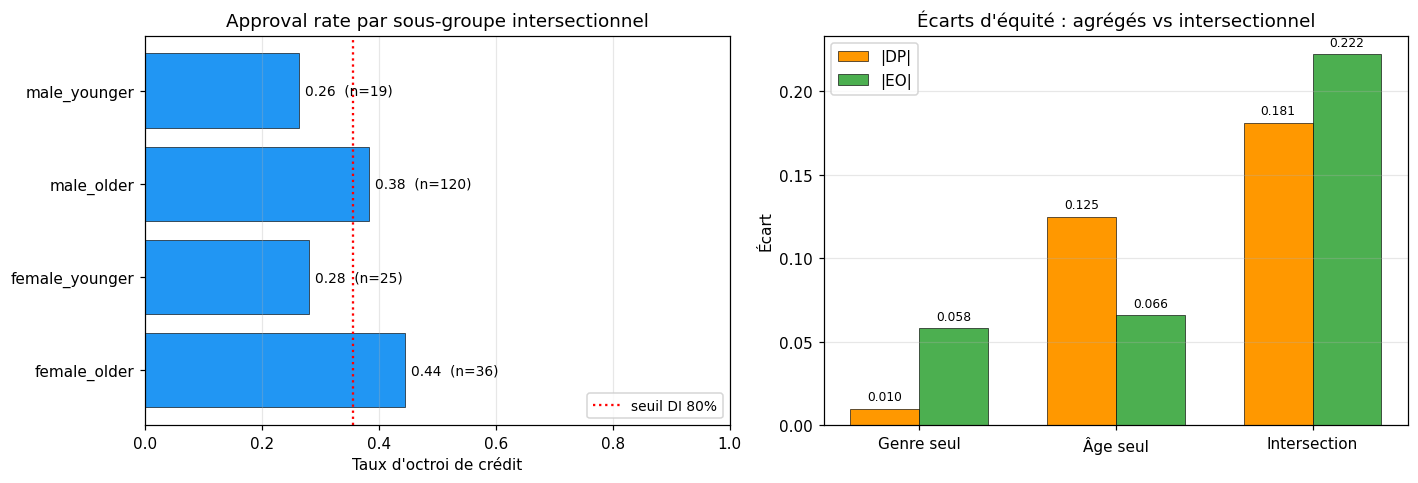

In [12]:
# Construire l'attribut intersectionnel
inter = np.array([f"{g}_{a}" for g, a in zip(sensitive["gender"][idx_te], sensitive["age"][idx_te])])

# Audit
dp_int, eo_int, di_int, by_group_int = fairness_summary(y_te, preds_base, inter)

# Tableau par sous-groupe
counts = pd.Series(inter).value_counts().sort_index()
by_group_int["n"] = counts
display(by_group_int.round(3))

print(f"\n|DP gap|              = {dp_int:.4f}  (vs 0.010 genre, 0.125 âge)")
print(f"|EO gap|              = {eo_int:.4f}")
print(f"Disparate Impact (DI) = {di_int:.4f}", "<-- < 0.8 = règle 80% violée" if di_int < 0.8 else "(>= 0.8)")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

groups = by_group_int.index.tolist()
ax = axes[0]
y_pos = np.arange(len(groups))
ax.barh(y_pos, by_group_int["approval_rate"], color="#2196F3", edgecolor="k", lw=0.4)
for i, (v, n) in enumerate(zip(by_group_int["approval_rate"], by_group_int["n"])):
    ax.text(v + 0.01, i, f"{v:.2f}  (n={n})", va="center", fontsize=9)
ax.axvline(by_group_int["approval_rate"].max() * 0.8, color="red", ls=":", lw=1.5,
           label="seuil DI 80%")
ax.set_yticks(y_pos); ax.set_yticklabels(groups)
ax.set_xlabel("Taux d'octroi de crédit")
ax.set_title("Approval rate par sous-groupe intersectionnel")
ax.set_xlim(0, 1)
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3, axis="x")

# Comparaison écarts agrégés vs intersectionnel
ax = axes[1]
gaps = pd.DataFrame([
    {"axe": "Genre seul",    "|DP|": 0.010, "|EO|": 0.058},
    {"axe": "Âge seul",      "|DP|": 0.125, "|EO|": 0.066},
    {"axe": "Intersection",  "|DP|": dp_int, "|EO|": eo_int},
])
x = np.arange(len(gaps))
width = 0.35
ax.bar(x - width/2, gaps["|DP|"], width, color="#FF9800", label="|DP|", edgecolor="k", lw=0.4)
ax.bar(x + width/2, gaps["|EO|"], width, color="#4CAF50", label="|EO|", edgecolor="k", lw=0.4)
ax.set_xticks(x); ax.set_xticklabels(gaps["axe"])
ax.set_ylabel("Écart")
ax.set_title("Écarts d'équité : agrégés vs intersectionnel")
for i, (dp, eo) in enumerate(zip(gaps["|DP|"], gaps["|EO|"])):
    ax.text(i - width/2, dp + 0.005, f"{dp:.3f}", ha="center", fontsize=8)
    ax.text(i + width/2, eo + 0.005, f"{eo:.3f}", ha="center", fontsize=8)
ax.legend()
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("outputs/14_intersectional.png", bbox_inches="tight")
plt.show()

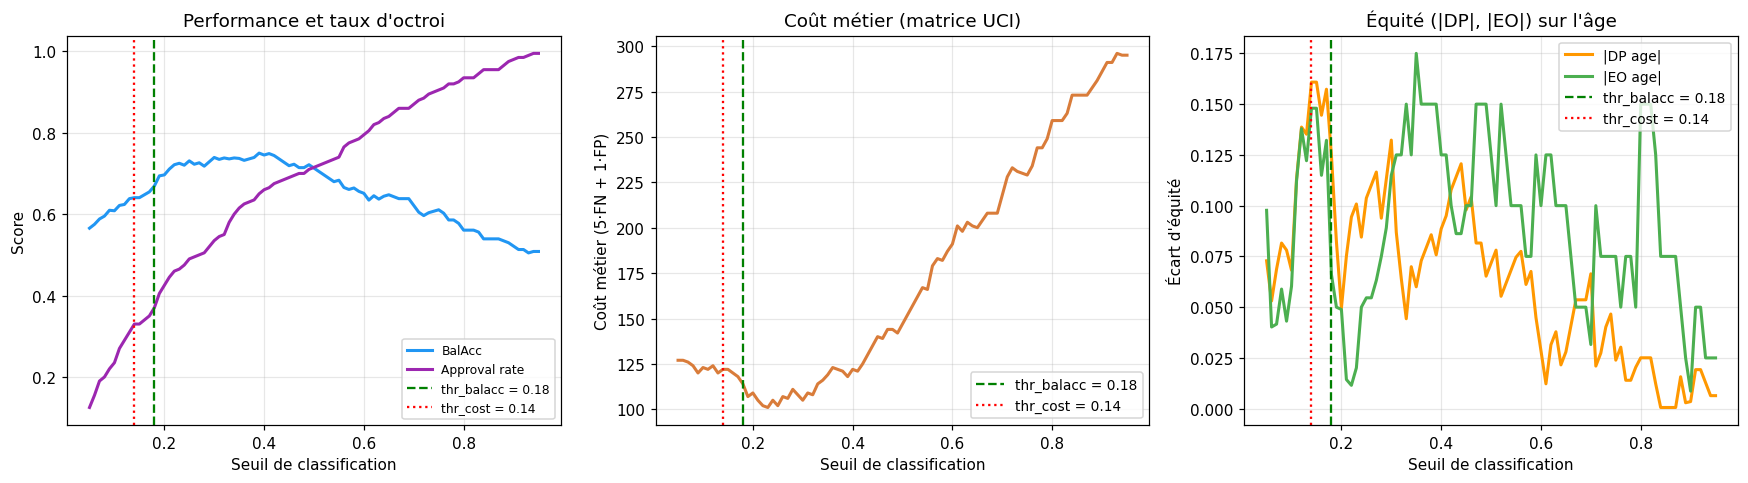

In [13]:
sweep_rows = []
for t in np.linspace(0.05, 0.95, 91):
    pr = (scores_base >= t).astype(int)
    s_age = sensitive["age"][idx_te]
    dp_age, eo_age, di_age, _ = fairness_summary(y_te, pr, s_age)
    sweep_rows.append({
        "threshold": t,
        "BalAcc": balanced_accuracy_score(y_te, pr),
        "Business cost": business_cost(y_te, pr),
        "DP age": dp_age,
        "EO age": eo_age,
        "Approval rate": float((pr == 0).mean()),
    })
sweep = pd.DataFrame(sweep_rows)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
ax.plot(sweep["threshold"], sweep["BalAcc"], "-", color="#2196F3", lw=2, label="BalAcc")
ax.plot(sweep["threshold"], sweep["Approval rate"], "-", color="#9C27B0", lw=2, label="Approval rate")
ax.axvline(thr_base, color="green", ls="--", lw=1.5, label=f"thr_balacc = {thr_base:.2f}")
ax.axvline(thr_cost, color="red",   ls=":",  lw=1.5, label=f"thr_cost = {thr_cost:.2f}")
ax.set_xlabel("Seuil de classification")
ax.set_ylabel("Score")
ax.set_title("Performance et taux d'octroi")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(sweep["threshold"], sweep["Business cost"], "-", color="#d97c3a", lw=2)
ax.axvline(thr_base, color="green", ls="--", lw=1.5, label=f"thr_balacc = {thr_base:.2f}")
ax.axvline(thr_cost, color="red",   ls=":",  lw=1.5, label=f"thr_cost = {thr_cost:.2f}")
ax.set_xlabel("Seuil de classification")
ax.set_ylabel("Coût métier (5·FN + 1·FP)")
ax.set_title("Coût métier (matrice UCI)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(sweep["threshold"], sweep["DP age"], "-", color="#FF9800", lw=2, label="|DP age|")
ax.plot(sweep["threshold"], sweep["EO age"], "-", color="#4CAF50", lw=2, label="|EO age|")
ax.axvline(thr_base, color="green", ls="--", lw=1.5, label=f"thr_balacc = {thr_base:.2f}")
ax.axvline(thr_cost, color="red",   ls=":",  lw=1.5, label=f"thr_cost = {thr_cost:.2f}")
ax.set_xlabel("Seuil de classification")
ax.set_ylabel("Écart d'équité")
ax.set_title("Équité (|DP|, |EO|) sur l'âge")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/11_threshold_sweep.png", bbox_inches="tight")
plt.show()

In [14]:
def reweighing_weights(y, sens):
    """w_i = P(S)P(Y) / P(S,Y) pour chaque exemple."""
    n = len(y)
    p_y = pd.Series(y).value_counts(normalize=True)
    p_s = pd.Series(sens).value_counts(normalize=True)
    joint = pd.DataFrame({"y": y, "s": sens}).groupby(["s", "y"]).size() / n
    weights = np.array([
        p_s[sens[i]] * p_y[y[i]] / max(joint.get((sens[i], y[i]), 1e-12), 1e-12)
        for i in range(n)
    ])
    return weights / weights.mean()

fair_models = {}
for attr in ["gender", "age"]:
    s_tr_attr = sensitive[attr][idx_tr]
    weights = reweighing_weights(y_tr, s_tr_attr)

    print(f"Reweighing {attr}")
    df_w = pd.DataFrame({"y": y_tr, "s": s_tr_attr, "w": weights})
    for (s, yy), grp in df_w.groupby(["s", "y"]):
        print(f"  ({s}, y={yy}) : poids moyen = {grp['w'].mean():.3f}  (n={len(grp)})")

    model = LogisticRegression(C=1.0, solver="liblinear", max_iter=1000, random_state=42)
    model.fit(X_tr, y_tr, sample_weight=weights)
    scores_va_f = model.predict_proba(X_va)[:, 1]
    thr_f = best_threshold(y_va, scores_va_f)
    fair_models[attr] = (model, thr_f)
    print(f"  seuil = {thr_f:.3f}\n")


Reweighing gender
  (female, y=0) : poids moyen = 1.053  (n=121)
  (female, y=1) : poids moyen = 0.895  (n=61)
  (male, y=0) : poids moyen = 0.979  (n=299)
  (male, y=1) : poids moyen = 1.054  (n=119)
  seuil = 0.170

Reweighing age
  (older, y=0) : poids moyen = 0.975  (n=356)
  (older, y=1) : poids moyen = 1.063  (n=140)
  (younger, y=0) : poids moyen = 1.138  (n=64)
  (younger, y=1) : poids moyen = 0.780  (n=40)
  seuil = 0.140



In [15]:
def group_thresholds(scores_val, sens_val, target_rate):
    """Pour chaque groupe, trouver le seuil qui rapproche le plus du target_rate."""
    thresholds = {}
    for g in np.unique(sens_val):
        m = sens_val == g
        candidates = np.linspace(0.05, 0.95, 181)
        rates = [(scores_val[m] >= t).mean() for t in candidates]
        thresholds[g] = float(candidates[int(np.argmin(np.abs(np.array(rates) - target_rate)))])
    return thresholds

def apply_group_thresholds(scores, sens, thresholds):
    preds = np.zeros(len(scores), dtype=int)
    for g, t in thresholds.items():
        m = sens == g
        preds[m] = (scores[m] >= t).astype(int)
    return preds

pp_thresholds = {}
for attr in ["gender", "age"]:
    s_va_attr = sensitive[attr][idx_va]
    target = (scores_va >= thr_base).mean()
    gt = group_thresholds(scores_va, s_va_attr, target)
    pp_thresholds[attr] = gt
    print(f"Seuils par groupe ({attr}, target={target:.3f}) : {gt}")

Seuils par groupe (gender, target=0.585) : {'female': 0.21999999999999997, 'male': 0.15499999999999997}
Seuils par groupe (age, target=0.585) : {'older': 0.15499999999999997, 'younger': 0.295}


In [16]:
all_results = {}

for attr in ["gender", "age"]:
    s_te_attr = sensitive[attr][idx_te]
    s_va_attr = sensitive[attr][idx_va]
    fair_model, thr_f = fair_models[attr]
    scores_fair = fair_model.predict_proba(X_te)[:, 1]
    scores_va_f = fair_model.predict_proba(X_va)[:, 1]

    target = (scores_va >= thr_base).mean()
    target_f = (scores_va_f >= thr_f).mean()
    gt_base = pp_thresholds[attr]
    gt_fair = group_thresholds(scores_va_f, s_va_attr, target_f)

    configs = {
        "Baseline":   (preds_base, scores_base),
        "Reweighing": ((scores_fair >= thr_f).astype(int), scores_fair),
        "Baseline+PP": (apply_group_thresholds(scores_base, s_te_attr, gt_base), scores_base),
        "Reweigh+PP": (apply_group_thresholds(scores_fair, s_te_attr, gt_fair), scores_fair),
    }

    rows = []
    for name, (preds, scores) in configs.items():
        p = perf_summary(y_te, preds, scores)
        dp, eo, _, _ = fairness_summary(y_te, preds, s_te_attr)
        rows.append({"Modèle": name, "AUC": p["AUC"], "BalAcc": p["BalAcc"],
                     "|DP|": dp, "|EO|": eo})
    df = pd.DataFrame(rows)
    all_results[attr] = df
    print(f"Configurations pour {attr}")
    print(df.to_string(index=False, float_format="{:.4f}".format))
    print()


Configurations pour gender
     Modèle    AUC  BalAcc   |DP|   |EO|
   Baseline 0.7851  0.6690 0.0101 0.0576
 Reweighing 0.7854  0.6655 0.0063 0.0500
Baseline+PP 0.7851  0.6690 0.1045 0.1956
 Reweigh+PP 0.7854  0.6690 0.1281 0.2301

Configurations pour age
     Modèle    AUC  BalAcc   |DP|   |EO|
   Baseline 0.7851  0.6690 0.1247 0.0661
 Reweighing 0.7842  0.6405 0.1317 0.0977
Baseline+PP 0.7851  0.6440 0.0600 0.1351
 Reweigh+PP 0.7842  0.6500 0.0688 0.2213



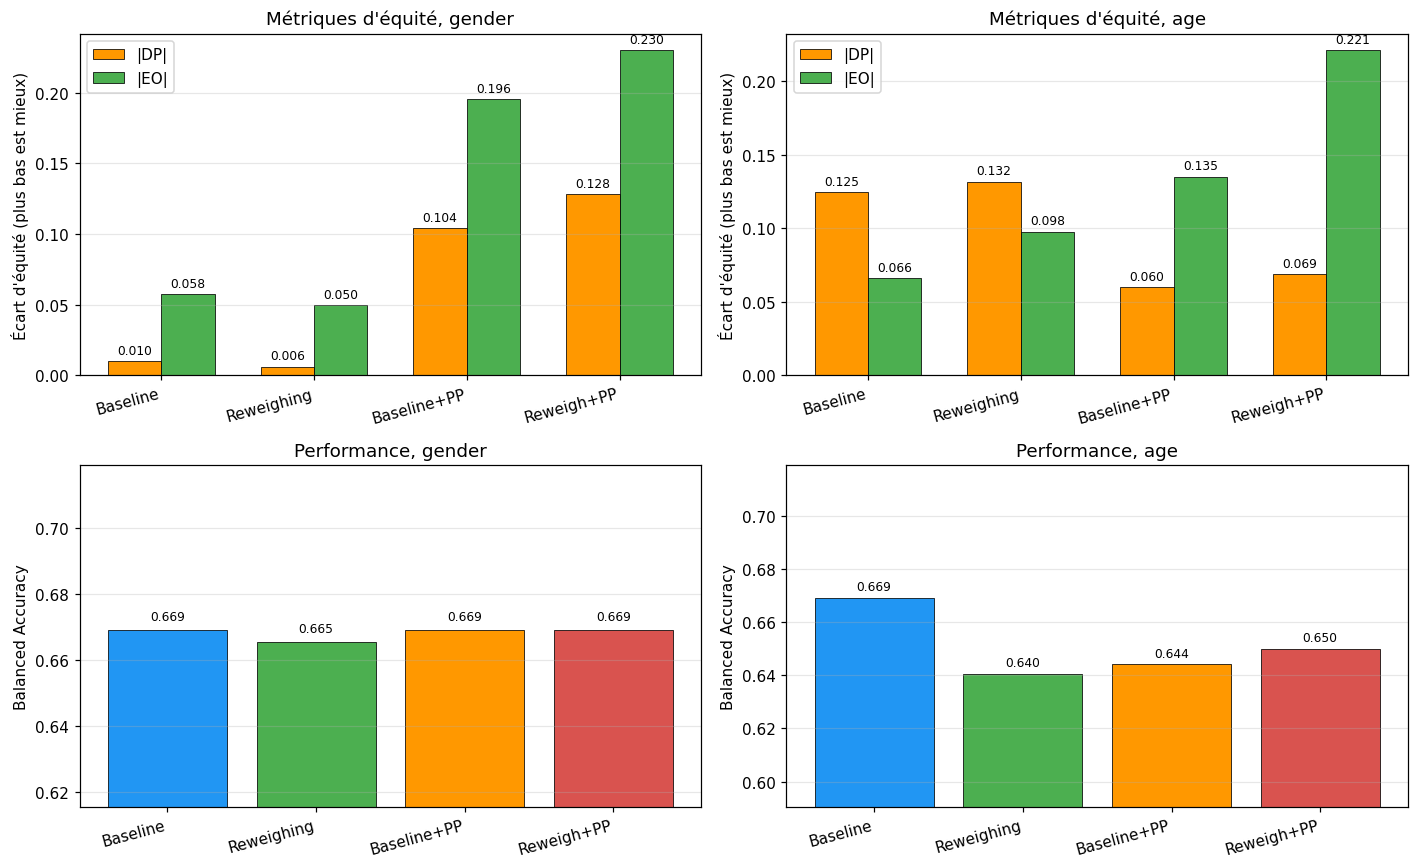

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
colors = ["#2196F3", "#4CAF50", "#FF9800", "#d9534f"]

for col, attr in enumerate(["gender", "age"]):
    df = all_results[attr]
    config_names = df["Modèle"].tolist()
    x = np.arange(len(config_names))

    ax = axes[0, col]
    width = 0.35
    ax.bar(x - width/2, df["|DP|"], width, color="#FF9800", label="|DP|", edgecolor="k", lw=0.5)
    ax.bar(x + width/2, df["|EO|"], width, color="#4CAF50", label="|EO|", edgecolor="k", lw=0.5)
    ax.set_xticks(x); ax.set_xticklabels(config_names, rotation=15, ha="right")
    ax.set_ylabel("Écart d'équité (plus bas est mieux)")
    ax.set_title(f"Métriques d'équité, {attr}")
    ax.legend()
    ax.grid(alpha=0.3, axis="y")
    for i, (dp, eo) in enumerate(zip(df["|DP|"], df["|EO|"])):
        ax.text(i - width/2, dp + 0.005, f"{dp:.3f}", ha="center", fontsize=8)
        ax.text(i + width/2, eo + 0.005, f"{eo:.3f}", ha="center", fontsize=8)

    ax = axes[1, col]
    ax.bar(x, df["BalAcc"], color=colors, edgecolor="k", lw=0.5)
    ax.set_xticks(x); ax.set_xticklabels(config_names, rotation=15, ha="right")
    ax.set_ylabel("Balanced Accuracy")
    ax.set_title(f"Performance, {attr}")
    ax.set_ylim(max(0, df["BalAcc"].min() - 0.05), min(1, df["BalAcc"].max() + 0.05))
    ax.grid(alpha=0.3, axis="y")
    for i, v in enumerate(df["BalAcc"]):
        ax.text(i, v + 0.003, f"{v:.3f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("outputs/02_tradeoff.png", bbox_inches="tight")
plt.show()


                  Stratégie  BalAcc   |DP|   |EO|     DI
         Baseline (sans PP)  0.6690 0.1247 0.0661 0.6862
             PP maison (DP)  0.6440 0.0600 0.1351 0.8610
fairlearn ThresholdOpt (EO)  0.6214 0.0082 0.1500 0.9906


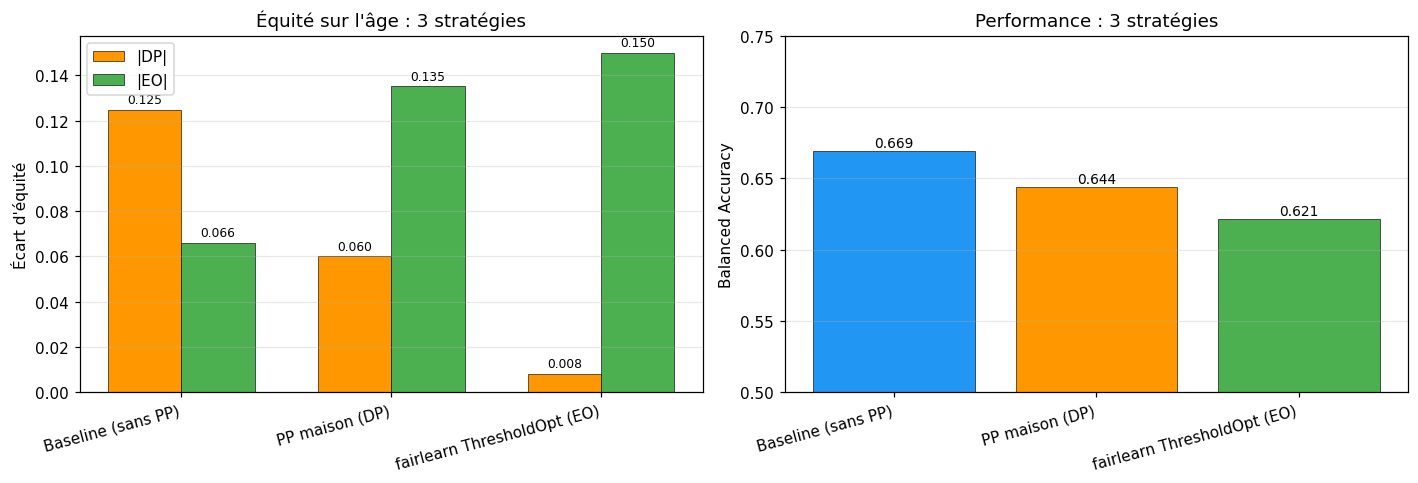

In [18]:
from fairlearn.postprocessing import ThresholdOptimizer

# Pour fairlearn, on utilise le modèle baseline déjà fitté (prefit=True)
to_eo = ThresholdOptimizer(
    estimator=baseline,
    constraints="equalized_odds",
    prefit=True,
    predict_method="predict_proba",
)
to_eo.fit(X_va, y_va, sensitive_features=sensitive["age"][idx_va])
preds_to_eo = to_eo.predict(X_te, sensitive_features=sensitive["age"][idx_te])

# Métriques pour les 3 stratégies sur l'âge
def row(name, preds):
    p = perf_summary(y_te, preds, scores_base)
    dp, eo, di, _ = fairness_summary(y_te, preds, sensitive["age"][idx_te])
    return {"Stratégie": name, "BalAcc": p["BalAcc"], "|DP|": dp, "|EO|": eo, "DI": di}

# PP maison Demographic Parity (déjà calculé dans la section 8)
preds_pp_dp = apply_group_thresholds(scores_base, sensitive["age"][idx_te], pp_thresholds["age"])

comparison = pd.DataFrame([
    row("Baseline (sans PP)",                preds_base),
    row("PP maison (DP)",                    preds_pp_dp),
    row("fairlearn ThresholdOpt (EO)",       preds_to_eo),
])
print(comparison.to_string(index=False, float_format="{:.4f}".format))

# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

x = np.arange(len(comparison))
width = 0.35

ax = axes[0]
ax.bar(x - width/2, comparison["|DP|"], width, color="#FF9800", label="|DP|", edgecolor="k", lw=0.4)
ax.bar(x + width/2, comparison["|EO|"], width, color="#4CAF50", label="|EO|", edgecolor="k", lw=0.4)
ax.set_xticks(x); ax.set_xticklabels(comparison["Stratégie"], rotation=15, ha="right")
ax.set_ylabel("Écart d'équité")
ax.set_title("Équité sur l'âge : 3 stratégies")
for i, (dp, eo) in enumerate(zip(comparison["|DP|"], comparison["|EO|"])):
    ax.text(i - width/2, dp + 0.003, f"{dp:.3f}", ha="center", fontsize=8)
    ax.text(i + width/2, eo + 0.003, f"{eo:.3f}", ha="center", fontsize=8)
ax.legend()
ax.grid(alpha=0.3, axis="y")

ax = axes[1]
ax.bar(x, comparison["BalAcc"], color=["#2196F3", "#FF9800", "#4CAF50"], edgecolor="k", lw=0.4)
ax.set_xticks(x); ax.set_xticklabels(comparison["Stratégie"], rotation=15, ha="right")
ax.set_ylabel("Balanced Accuracy")
ax.set_title("Performance : 3 stratégies")
ax.set_ylim(0.5, 0.75)
for i, v in enumerate(comparison["BalAcc"]):
    ax.text(i, v + 0.003, f"{v:.3f}", ha="center", fontsize=9)
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("outputs/15_fairlearn_postproc.png", bbox_inches="tight")
plt.show()

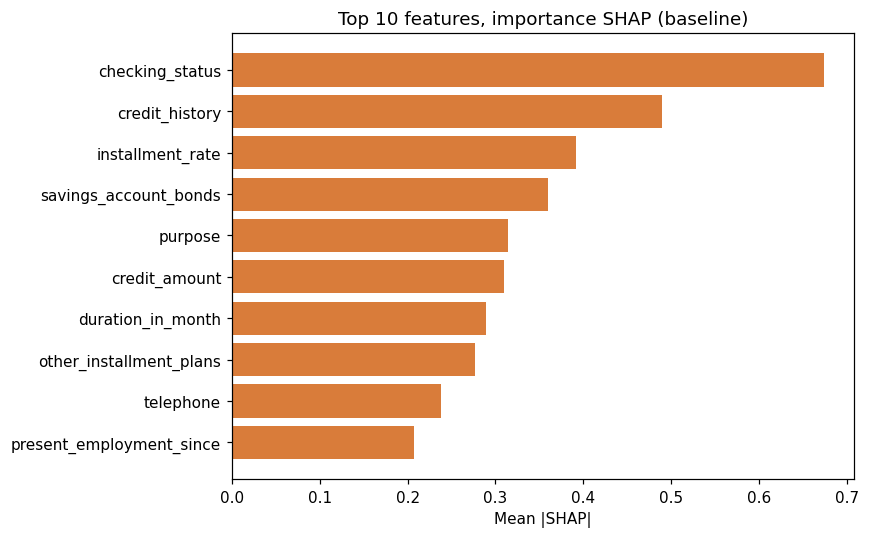

In [19]:
import shap

explainer = shap.LinearExplainer(baseline, X_tr, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_te)

shap_by_feature = {}
for col in NUMERIC:
    j = feature_names.index(col)
    shap_by_feature[col] = float(np.abs(shap_values[:, j]).mean())

for col in CATEG:
    indices = [k for k, n in enumerate(feature_names) if n.startswith(col + "_")]
    if indices:
        shap_by_feature[col] = float(np.abs(shap_values[:, indices].sum(axis=1)).mean())

shap_df = pd.DataFrame(
    {"feature": list(shap_by_feature.keys()), "importance": list(shap_by_feature.values())}
).sort_values("importance", ascending=False).reset_index(drop=True)

top = shap_df.head(10).sort_values("importance")
plt.figure(figsize=(8, 5))
plt.barh(top["feature"], top["importance"], color="#d97c3a")
plt.xlabel("Mean |SHAP|")
plt.title("Top 10 features, importance SHAP (baseline)")
plt.tight_layout()
plt.savefig("outputs/03_shap.png", bbox_inches="tight")
plt.show()

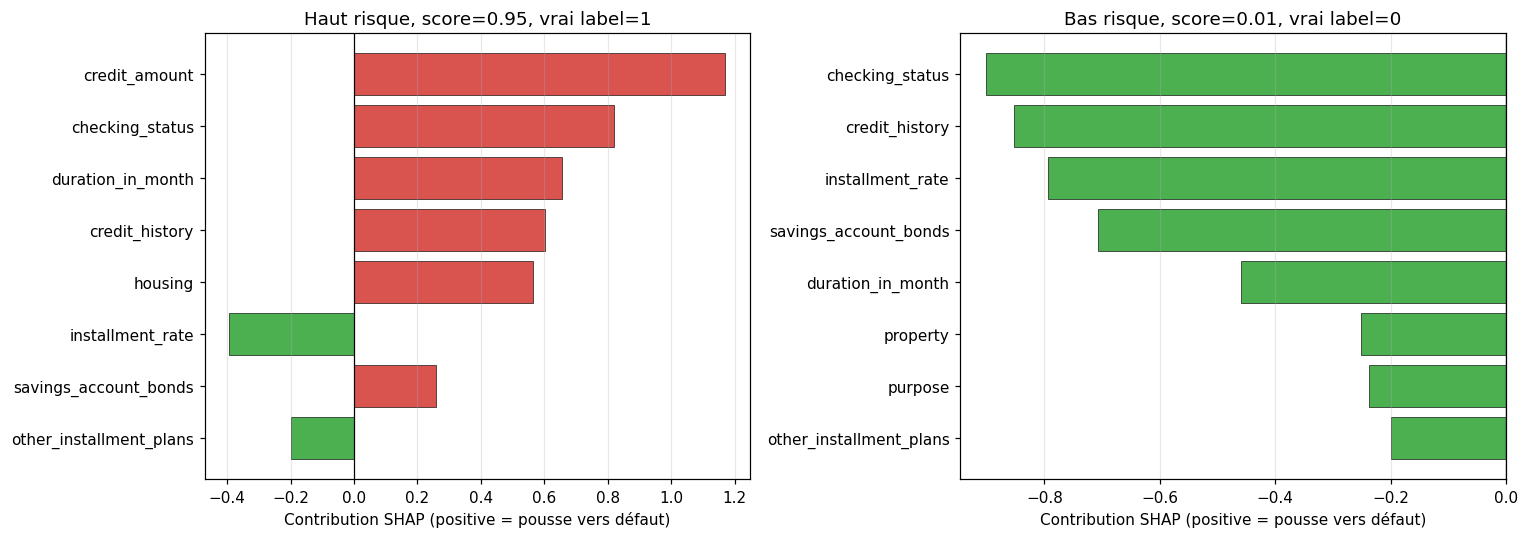

Lecture : barres rouges = features qui poussent la prédiction vers 'défaut',
          barres vertes = features qui poussent vers 'bon payeur'.
Le client haut risque a un score de 0.952 (vrai label : 1)
Le client bas risque a un score de 0.007 (vrai label : 0)


In [20]:
# Sélection de deux clients représentatifs : haut risque vs bas risque
idx_high = int(np.argmax(scores_base))
idx_low  = int(np.argmin(scores_base))

def shap_local_by_feature(idx):
    contribs = shap_values[idx]
    by_feat = {}
    for col in NUMERIC:
        j = feature_names.index(col)
        by_feat[col] = float(contribs[j])
    for col in CATEG:
        indices = [k for k, n in enumerate(feature_names) if n.startswith(col + "_")]
        if indices:
            by_feat[col] = float(contribs[indices].sum())
    return by_feat

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, idx, label in [
    (axes[0], idx_high, f"Haut risque, score={scores_base[idx_high]:.2f}, vrai label={int(y_te[idx_high])}"),
    (axes[1], idx_low,  f"Bas risque, score={scores_base[idx_low]:.2f}, vrai label={int(y_te[idx_low])}"),
]:
    by_feat = shap_local_by_feature(idx)
    df = pd.DataFrame({"feature": list(by_feat.keys()), "shap": list(by_feat.values())})
    df = df.reindex(df["shap"].abs().sort_values(ascending=False).index).head(8).iloc[::-1]
    colors = ["#d9534f" if v > 0 else "#4CAF50" for v in df["shap"]]
    ax.barh(df["feature"], df["shap"], color=colors, edgecolor="k", lw=0.4)
    ax.axvline(0, color="k", lw=0.8)
    ax.set_title(label)
    ax.set_xlabel("Contribution SHAP (positive = pousse vers défaut)")
    ax.grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("outputs/09_shap_local.png", bbox_inches="tight")
plt.show()

print("Lecture : barres rouges = features qui poussent la prédiction vers 'défaut',")
print("          barres vertes = features qui poussent vers 'bon payeur'.")
print(f"Le client haut risque a un score de {scores_base[idx_high]:.3f} (vrai label : {int(y_te[idx_high])})")
print(f"Le client bas risque a un score de {scores_base[idx_low]:.3f} (vrai label : {int(y_te[idx_low])})")

In [21]:
X_te_df = pd.DataFrame(X_te, columns=feature_names)
X_tr_df = pd.DataFrame(X_tr, columns=feature_names)

proxy_summary = []

for attr in ["gender", "age"]:
    code_map = {"male": 1, "female": 0, "older": 1, "younger": 0}
    s_tr_num = pd.Series(sensitive[attr][idx_tr]).map(code_map).astype(int).values
    s_te_num = pd.Series(sensitive[attr][idx_te]).map(code_map).astype(float)

    # Approche 1 : corrélation univariée
    corr = X_te_df.corrwith(s_te_num).abs().sort_values(ascending=False).head(5)
    print(f"Top 5 proxies univariés pour {attr}")
    for feat, c in corr.items():
        flag = "  [proxy]" if c > 0.15 else ""
        print(f"  {feat:50s}  |r| = {c:.3f}{flag}")

    # Approche 2 : régression logistique multivariée (features -> attribut sensible)
    proxy_clf = LogisticRegression(C=1.0, solver="liblinear", max_iter=1000, random_state=42)
    proxy_clf.fit(X_tr_df.values, s_tr_num)
    proxy_scores_te = proxy_clf.predict_proba(X_te_df.values)[:, 1]
    auc_proxy = roc_auc_score(s_te_num.astype(int), proxy_scores_te)

    # Top features (coefficients standardisés)
    coefs = pd.Series(np.abs(proxy_clf.coef_[0]), index=feature_names).sort_values(ascending=False).head(5)

    print(f"\nRégression logistique features -> {attr} :")
    print(f"  AUC = {auc_proxy:.3f}  (>0.5 = l'attribut sensible est prédictible depuis les features)")
    print(f"  Top 5 features par |coef| :")
    for feat, c in coefs.items():
        print(f"    {feat:50s}  |coef| = {c:.3f}")
    print()

    proxy_summary.append({"attribut": attr, "AUC_proxy": auc_proxy,
                          "interprétation": "discrimination indirecte possible" if auc_proxy > 0.6 else "faible signal proxy"})

print("Synthèse")
print(pd.DataFrame(proxy_summary).to_string(index=False))


Top 5 proxies univariés pour gender
  number_of_people_liable                             |r| = 0.230  [proxy]
  present_employment_since_ancienneté >= 7 ans        |r| = 0.213  [proxy]
  housing_locataire                                   |r| = 0.209  [proxy]
  housing_hébergé gratuitement                        |r| = 0.198  [proxy]
  installment_rate                                    |r| = 0.171  [proxy]

Régression logistique features -> gender :
  AUC = 0.688  (>0.5 = l'attribut sensible est prédictible depuis les features)
  Top 5 features par |coef| :
    job_sans emploi / non qualifié non-résident         |coef| = 0.826
    present_employment_since_< 1 an                     |coef| = 0.776
    purpose_éducation                                   |coef| = 0.749
    purpose_réparations                                 |coef| = 0.649
    purpose_business                                    |coef| = 0.636

Top 5 proxies univariés pour age
  housing_locataire                           

In [22]:
# Construire le pipeline AVEC les attributs sensibles
features_with = raw.drop(columns=["raw_target", "default", "gender", "age_group"])
NUMERIC_with = NUMERIC + ["age_in_years"]
CATEG_with = [c for c in features_with.columns if c not in NUMERIC_with]

preprocessor_with = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC_with),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEG_with),
])

X_tr_with = preprocessor_with.fit_transform(features_with.iloc[idx_tr])
X_te_with = preprocessor_with.transform(features_with.iloc[idx_te])
feature_names_with = [n.split("__", 1)[-1] for n in preprocessor_with.get_feature_names_out()]

baseline_with = LogisticRegression(C=1.0, solver="liblinear", max_iter=1000, random_state=42)
baseline_with.fit(X_tr_with, y_tr)

# SHAP sur le modèle AVEC attributs sensibles
explainer_with = shap.LinearExplainer(baseline_with, X_tr_with, feature_perturbation="interventional")
shap_values_with = explainer_with.shap_values(X_te_with)

shap_with_by_feature = {}
for col in NUMERIC_with:
    j = feature_names_with.index(col)
    shap_with_by_feature[col] = float(np.abs(shap_values_with[:, j]).mean())
for col in CATEG_with:
    indices = [k for k, n in enumerate(feature_names_with) if n.startswith(col + "_")]
    if indices:
        shap_with_by_feature[col] = float(np.abs(shap_values_with[:, indices].sum(axis=1)).mean())

# AUC du modèle AVEC attributs sensibles (comparaison de performance)
auc_with = roc_auc_score(y_te, baseline_with.predict_proba(X_te_with)[:, 1])
auc_without = roc_auc_score(y_te, scores_base)
print(f"AUC test, modèle AVEC attributs sensibles    : {auc_with:.4f}")
print(f"AUC test, modèle SANS attributs sensibles    : {auc_without:.4f}")
print(f"Coût en performance du retrait              : {auc_with - auc_without:+.4f}")


AUC test, modèle AVEC attributs sensibles    : 0.7813
AUC test, modèle SANS attributs sensibles    : 0.7851
Coût en performance du retrait              : -0.0038


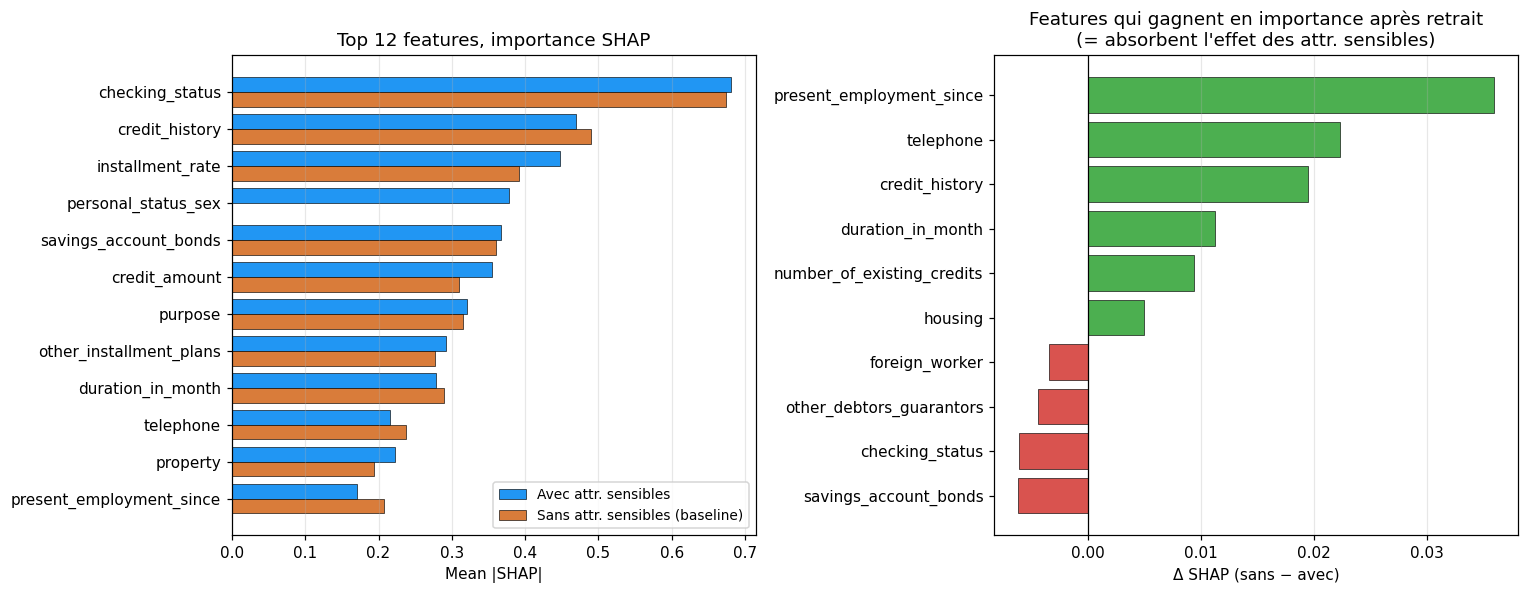


Top 5 features qui ABSORBENT l'effet des attributs sensibles :
                   feature   avec   sans  delta
  present_employment_since 0.1709 0.2068 0.0360
                 telephone 0.2156 0.2379 0.0223
            credit_history 0.4698 0.4893 0.0195
         duration_in_month 0.2779 0.2891 0.0113
number_of_existing_credits 0.1404 0.1498 0.0094


In [23]:
# Visualisation côte-à-côte
all_feats = sorted(set(shap_by_feature) | set(shap_with_by_feature),
                   key=lambda f: -max(shap_by_feature.get(f, 0), shap_with_by_feature.get(f, 0)))
top_n = 12
top_feats = all_feats[:top_n]
imp_without = np.array([shap_by_feature.get(f, 0) for f in top_feats])
imp_with = np.array([shap_with_by_feature.get(f, 0) for f in top_feats])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

y_pos = np.arange(len(top_feats))
width = 0.4
axes[0].barh(y_pos - width/2, imp_with, width, color="#2196F3",
             label="Avec attr. sensibles", edgecolor="k", lw=0.4)
axes[0].barh(y_pos + width/2, imp_without, width, color="#d97c3a",
             label="Sans attr. sensibles (baseline)", edgecolor="k", lw=0.4)
axes[0].set_yticks(y_pos); axes[0].set_yticklabels(top_feats)
axes[0].set_xlabel("Mean |SHAP|")
axes[0].set_title("Top 12 features, importance SHAP")
axes[0].invert_yaxis()
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3, axis="x")

# Delta : qui gagne en importance après retrait ?
all_keys = list(set(shap_by_feature) | set(shap_with_by_feature))
delta = pd.DataFrame({
    "feature": all_keys,
    "avec":   [shap_with_by_feature.get(f, 0) for f in all_keys],
    "sans":   [shap_by_feature.get(f, 0) for f in all_keys],
})
delta["delta"] = delta["sans"] - delta["avec"]
delta = delta.sort_values("delta", ascending=False).head(10)

colors = ["#4CAF50" if d > 0 else "#d9534f" for d in delta["delta"]]
axes[1].barh(np.arange(len(delta)), delta["delta"], color=colors, edgecolor="k", lw=0.4)
axes[1].set_yticks(np.arange(len(delta))); axes[1].set_yticklabels(delta["feature"])
axes[1].set_xlabel("Δ SHAP (sans − avec)")
axes[1].set_title("Features qui gagnent en importance après retrait\n(= absorbent l'effet des attr. sensibles)")
axes[1].invert_yaxis()
axes[1].axvline(0, color="k", lw=0.8)
axes[1].grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("outputs/08_shap_compare.png", bbox_inches="tight")
plt.show()

print()
print("Top 5 features qui ABSORBENT l'effet des attributs sensibles :")
print(delta.head(5).to_string(index=False, float_format="{:.4f}".format))


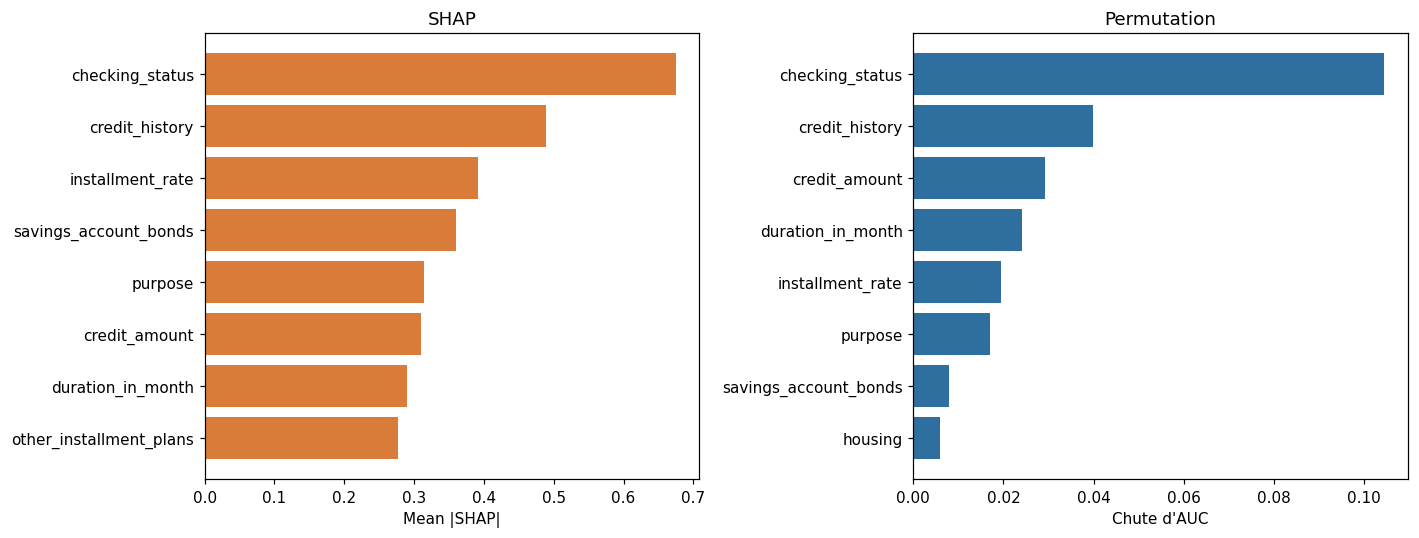

In [24]:
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline

pipe = Pipeline([("prep", preprocessor), ("clf", baseline)])
pipe.fit(features.iloc[idx_tr], y_tr)

perm = permutation_importance(
    pipe, features.iloc[idx_te], y_te,
    n_repeats=10, random_state=42, scoring="roc_auc", n_jobs=1,
)
perm_df = pd.DataFrame(
    {"feature": features.columns, "auc_drop": perm.importances_mean}
).sort_values("auc_drop", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
top_s = shap_df.head(8).sort_values("importance")
top_p = perm_df.head(8).sort_values("auc_drop")
axes[0].barh(top_s["feature"], top_s["importance"], color="#d97c3a")
axes[0].set_title("SHAP")
axes[0].set_xlabel("Mean |SHAP|")
axes[1].barh(top_p["feature"], top_p["auc_drop"], color="#2f6f9f")
axes[1].set_title("Permutation")
axes[1].set_xlabel("Chute d'AUC")
plt.tight_layout()
plt.savefig("outputs/04_shap_vs_perm.png", bbox_inches="tight")
plt.show()

In [25]:
from sklearn.utils import resample

B = 200
boot_scores = np.zeros((B, len(idx_te)))
boot_metrics = {"AUC": [], "BalAcc": [], "DP_gender": [], "EO_gender": [],
                "DP_age": [], "EO_age": []}
rng_b = np.random.default_rng(0)

for b in range(B):
    idx_boot = resample(np.arange(len(idx_tr)), replace=True,
                        n_samples=len(idx_tr), random_state=int(rng_b.integers(0, 1 << 31)))
    model_b = LogisticRegression(C=1.0, solver="liblinear", max_iter=1000, random_state=42)
    model_b.fit(X_tr[idx_boot], y_tr[idx_boot])
    s_b = model_b.predict_proba(X_te)[:, 1]
    boot_scores[b] = s_b
    p_b = (s_b >= thr_base).astype(int)

    boot_metrics["AUC"].append(roc_auc_score(y_te, s_b))
    boot_metrics["BalAcc"].append(balanced_accuracy_score(y_te, p_b))
    for attr in ["gender", "age"]:
        s_te_attr = sensitive[attr][idx_te]
        dp, eo, _, _ = fairness_summary(y_te, p_b, s_te_attr)
        boot_metrics[f"DP_{attr}"].append(dp)
        boot_metrics[f"EO_{attr}"].append(eo)

ci_rows = []
for k, vals in boot_metrics.items():
    arr = np.asarray(vals)
    ci_rows.append({
        "métrique": k, "moyenne": arr.mean(), "écart-type": arr.std(),
        "IC 2.5%": np.quantile(arr, 0.025), "IC 97.5%": np.quantile(arr, 0.975),
    })
ci_df = pd.DataFrame(ci_rows)
print(f"Intervalles de confiance bootstrap (B={B})")
print(ci_df.to_string(index=False, float_format="{:.4f}".format))


Intervalles de confiance bootstrap (B=200)
 métrique  moyenne  écart-type  IC 2.5%  IC 97.5%
      AUC   0.7639      0.0193   0.7231    0.7953
   BalAcc   0.6822      0.0228   0.6369    0.7262
DP_gender   0.0347      0.0278   0.0006    0.1050
EO_gender   0.0892      0.0438   0.0172    0.1755
   DP_age   0.1035      0.0464   0.0204    0.2016
   EO_age   0.0857      0.0484   0.0184    0.1941


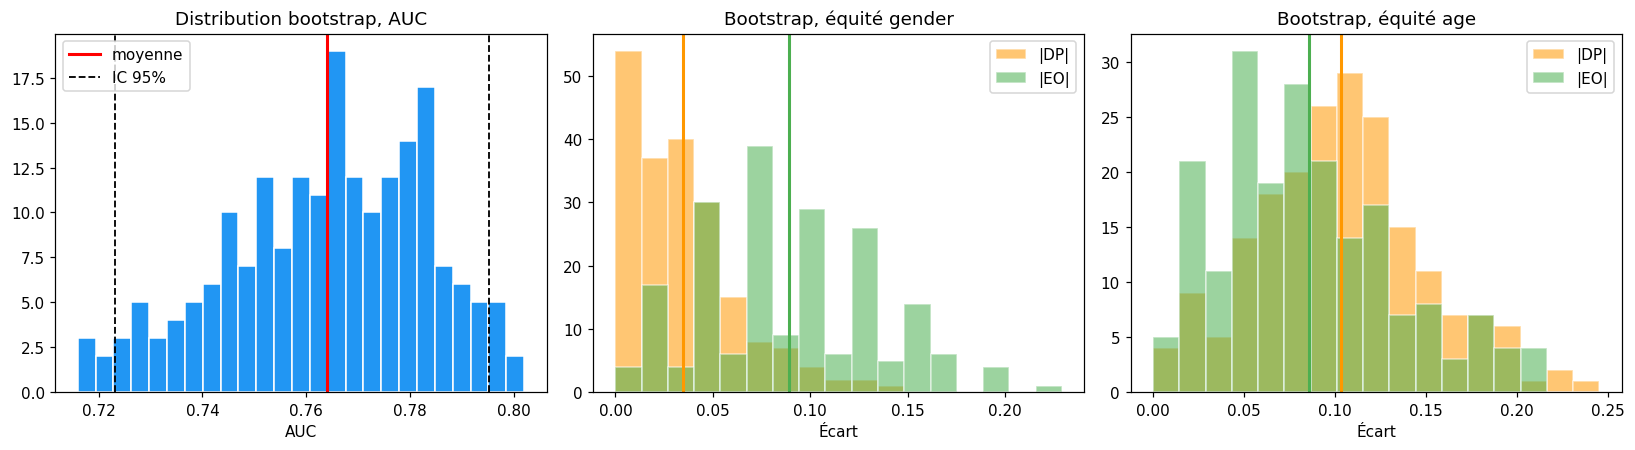

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].hist(boot_metrics["AUC"], bins=25, color="#2196F3", edgecolor="white")
axes[0].axvline(np.mean(boot_metrics["AUC"]), color="red", lw=2, label="moyenne")
axes[0].axvline(np.quantile(boot_metrics["AUC"], 0.025), color="k", ls="--", lw=1.2, label="IC 95%")
axes[0].axvline(np.quantile(boot_metrics["AUC"], 0.975), color="k", ls="--", lw=1.2)
axes[0].set_title("Distribution bootstrap, AUC")
axes[0].set_xlabel("AUC")
axes[0].legend()

for i, attr in enumerate(["gender", "age"], start=1):
    vals_dp = np.asarray(boot_metrics[f"DP_{attr}"])
    vals_eo = np.asarray(boot_metrics[f"EO_{attr}"])
    edges = np.linspace(0, max(vals_dp.max(), vals_eo.max()) * 1.05, 18)
    axes[i].hist(vals_dp, bins=edges, alpha=0.55, color="#FF9800", label="|DP|", edgecolor="white")
    axes[i].hist(vals_eo, bins=edges, alpha=0.55, color="#4CAF50", label="|EO|", edgecolor="white")
    axes[i].axvline(np.mean(vals_dp), color="#FF9800", lw=2, ls="-")
    axes[i].axvline(np.mean(vals_eo), color="#4CAF50", lw=2, ls="-")
    axes[i].set_title(f"Bootstrap, équité {attr}")
    axes[i].set_xlabel("Écart")
    axes[i].legend()

plt.tight_layout()
plt.savefig("outputs/05_bootstrap.png", bbox_inches="tight")
plt.show()


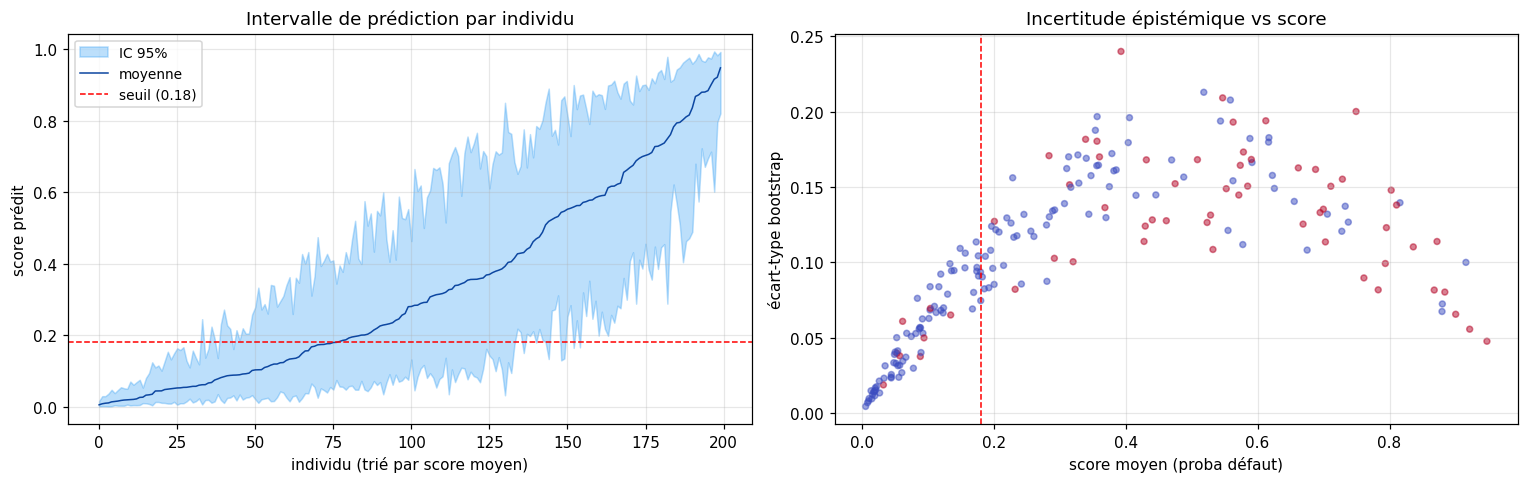

Écart-type moyen sur les scores : 0.1045
Écart-type max : 0.2400  (incertitude épistémique max)


In [27]:
score_mean = boot_scores.mean(axis=0)
score_std = boot_scores.std(axis=0)
score_lo = np.quantile(boot_scores, 0.025, axis=0)
score_hi = np.quantile(boot_scores, 0.975, axis=0)

order = np.argsort(score_mean)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

x = np.arange(len(order))
axes[0].fill_between(x, score_lo[order], score_hi[order],
                     alpha=0.3, color="#2196F3", label="IC 95%")
axes[0].plot(x, score_mean[order], color="#0d47a1", lw=1, label="moyenne")
axes[0].axhline(thr_base, color="red", ls="--", lw=1, label=f"seuil ({thr_base:.2f})")
axes[0].set_xlabel("individu (trié par score moyen)")
axes[0].set_ylabel("score prédit")
axes[0].set_title("Intervalle de prédiction par individu")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].scatter(score_mean, score_std, s=15, alpha=0.5, c=y_te, cmap="coolwarm")
axes[1].set_xlabel("score moyen (proba défaut)")
axes[1].set_ylabel("écart-type bootstrap")
axes[1].set_title("Incertitude épistémique vs score")
axes[1].axvline(thr_base, color="red", ls="--", lw=1)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/06_indiv_uncertainty.png", bbox_inches="tight")
plt.show()

print(f"Écart-type moyen sur les scores : {score_std.mean():.4f}")
print(f"Écart-type max : {score_std.max():.4f}  (incertitude épistémique max)")

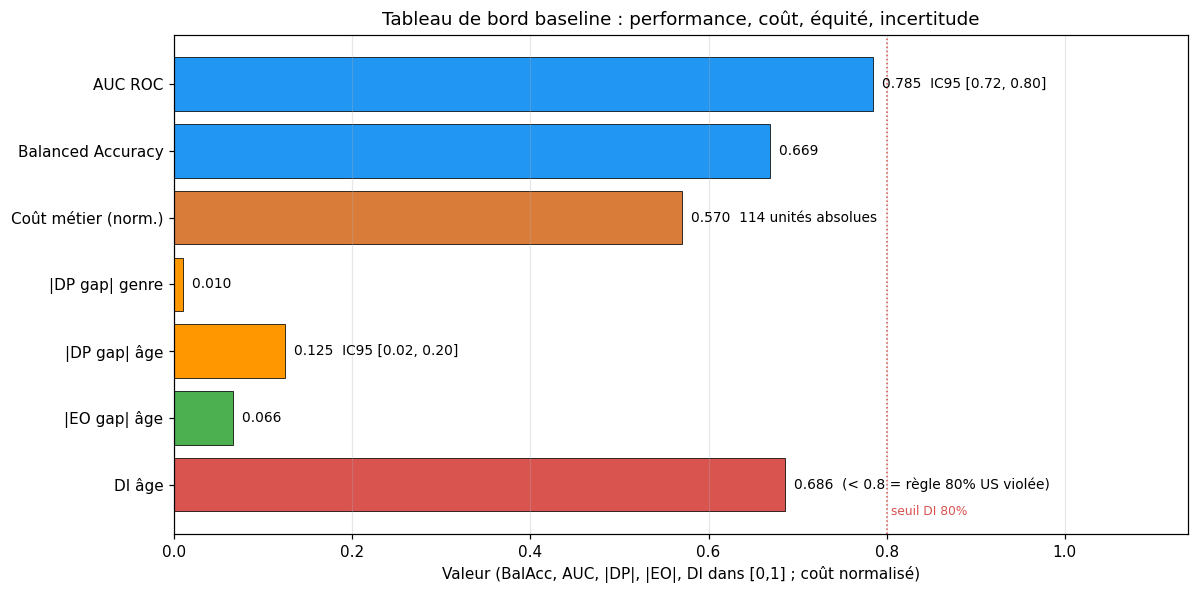

In [28]:
# Récupère les valeurs depuis les variables déjà définies plus haut
auc_val          = roc_auc_score(y_te, scores_base)
balacc_val       = balanced_accuracy_score(y_te, preds_base)
cost_val         = business_cost(y_te, preds_base)
dp_g, eo_g, di_g, _ = fairness_summary(y_te, preds_base, sensitive["gender"][idx_te])
dp_a, eo_a, di_a, _ = fairness_summary(y_te, preds_base, sensitive["age"][idx_te])
auc_ic = (np.quantile(boot_metrics["AUC"], 0.025), np.quantile(boot_metrics["AUC"], 0.975))
dp_age_ic = (np.quantile(boot_metrics["DP_age"], 0.025), np.quantile(boot_metrics["DP_age"], 0.975))

categories = [
    ("AUC ROC",            auc_val,    f"IC95 [{auc_ic[0]:.2f}, {auc_ic[1]:.2f}]", "#2196F3"),
    ("Balanced Accuracy",  balacc_val, "",                                          "#2196F3"),
    ("Coût métier (norm.)", cost_val/200, f"{cost_val} unités absolues",            "#d97c3a"),
    ("|DP gap| genre",     dp_g,       "",                                          "#FF9800"),
    ("|DP gap| âge",       dp_a,       f"IC95 [{dp_age_ic[0]:.2f}, {dp_age_ic[1]:.2f}]", "#FF9800"),
    ("|EO gap| âge",       eo_a,       "",                                          "#4CAF50"),
    ("DI âge",             di_a,       "(< 0.8 = règle 80% US violée)",             "#d9534f"),
]
labels = [c[0] for c in categories]
values = [c[1] for c in categories]
notes  = [c[2] for c in categories]
colors = [c[3] for c in categories]

fig, ax = plt.subplots(figsize=(11, 5.5))
y_pos = np.arange(len(labels))
bars = ax.barh(y_pos, values, color=colors, edgecolor="k", lw=0.5)
for i, (v, n) in enumerate(zip(values, notes)):
    ax.text(v + 0.01, i, f"{v:.3f}  {n}", va="center", fontsize=9)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlim(0, max(values) * 1.45)
ax.axvline(0.8, color="#d9534f", ls=":", lw=1)
ax.text(0.8, len(labels) - 0.5, " seuil DI 80%", color="#d9534f", fontsize=8, va="bottom")
ax.set_title("Tableau de bord baseline : performance, coût, équité, incertitude")
ax.set_xlabel("Valeur (BalAcc, AUC, |DP|, |EO|, DI dans [0,1] ; coût normalisé)")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("outputs/12_dashboard.png", bbox_inches="tight")
plt.show()